In [1]:
import pandas as pd

df = pd.read_csv("cgpa.csv")
df.head()

,SN,PRN,Name,Roll No,Sem1_CGPA,Sem2_CGPA,Sem3_CGPA,Sem4_CGPA,Sem5_CGPA,Avg_CGPA
0,1,72257851C,ADSUL YASHRAJ APPASAHEB,A-1,8.95,7.83,6.85,7.56,5.38,7.31
1,12,72331835C,ABHISHEK SANTOSH JUNGADE,A-2,9.01,5.23,8.07,8.86,5.33,7.30
2,23,72331839F,ADITI GEDAM,A-3,8.15,5.82,6.26,8.92,6.12,7.05
3,34,72331840K,ADITI GUPTA,A-4,8.16,8.49,7.06,7.43,7.42,7.71
4,45,72331842F,ADKAR ATHARVA SUNIL,A-5,9.40,9.11,9.03,9.30,9.30,9.23


In [2]:
df.isnull().sum()

SN           0
PRN          0
Name         0
Roll No      0
Sem1_CGPA    0
Sem2_CGPA    0
Sem3_CGPA    0
Sem4_CGPA    0
Sem5_CGPA    0
Avg_CGPA     0
dtype: int64

In [3]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df.isnull().sum()

SN           0
PRN          0
Name         0
Roll No      0
Sem1_CGPA    0
Sem2_CGPA    0
Sem3_CGPA    0
Sem4_CGPA    0
Sem5_CGPA    0
Avg_CGPA     0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

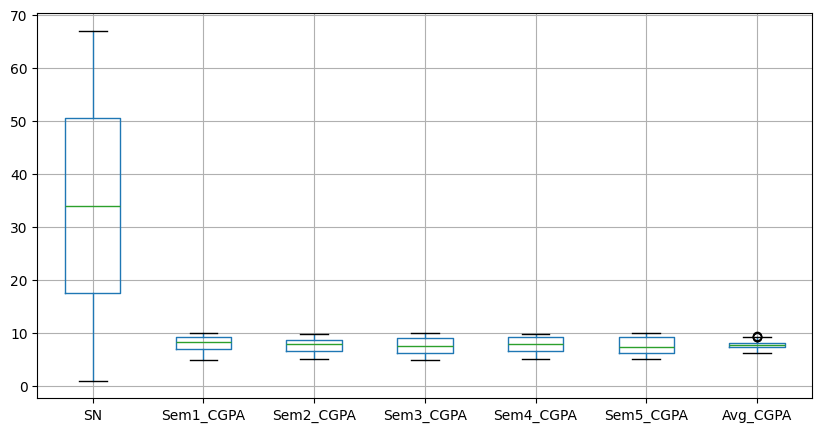

In [6]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include='number')

numeric_df.boxplot(figsize=(10,5))
plt.show()

In [7]:
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR)))
outliers.sum()

SN           0
Sem1_CGPA    0
Sem2_CGPA    0
Sem3_CGPA    0
Sem4_CGPA    0
Sem5_CGPA    0
Avg_CGPA     3
dtype: int64

In [8]:
df[numeric_df.columns] = numeric_df.clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR, axis=1)

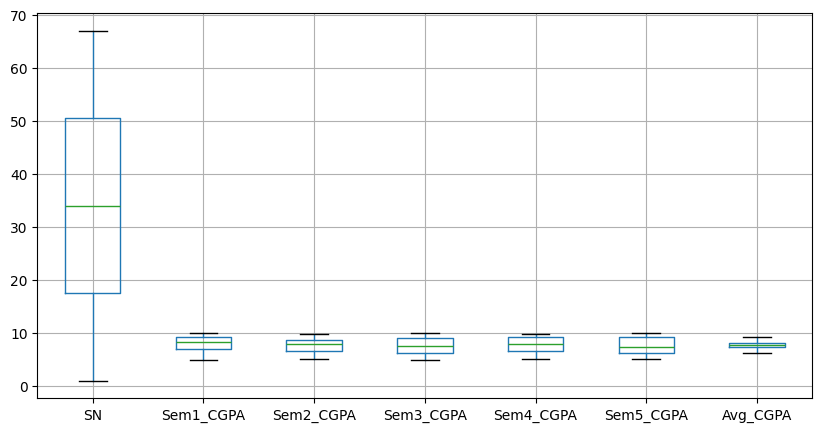

In [9]:
numeric_df = df.select_dtypes(include='number')

numeric_df.boxplot(figsize=(10,5))
plt.show()

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = ["Sem1_CGPA","Sem2_CGPA","Sem3_CGPA","Sem4_CGPA","Sem5_CGPA","Avg_CGPA"]
df[cols] = scaler.fit_transform(df[cols])

df[cols].head()


,Sem1_CGPA,Sem2_CGPA,Sem3_CGPA,Sem4_CGPA,Sem5_CGPA,Avg_CGPA
0,0.797571,0.571429,0.371486,0.520833,0.055215,0.363929
1,0.809717,0.025210,0.616466,0.791667,0.044990,0.360709
2,0.635628,0.149160,0.253012,0.804167,0.206544,0.280193
3,0.637652,0.710084,0.413655,0.493750,0.472393,0.492754
4,0.888664,0.840336,0.809237,0.883333,0.856851,0.982287


In [11]:
df[cols].describe()

,Sem1_CGPA,Sem2_CGPA,Sem3_CGPA,Sem4_CGPA,Sem5_CGPA,Avg_CGPA
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000
mean,0.618648,0.539728,0.494096,0.585292,0.507859,0.499171
std,0.282352,0.285294,0.298861,0.307861,0.308257,0.241384
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.393725,0.330882,0.241968,0.326042,0.228016,0.355878
50%,0.655870,0.600840,0.514056,0.610417,0.472393,0.476651
75%,0.844130,0.763655,0.798193,0.866667,0.829243,0.613527
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
numeric_cols = df.select_dtypes(include=['number'])
skewness = numeric_cols.skew()

print("Skewness values:\n")
print(skewness)

Skewness values:

SN           0.000000
Sem1_CGPA   -0.472023
Sem2_CGPA   -0.397238
Sem3_CGPA   -0.089867
Sem4_CGPA   -0.426398
Sem5_CGPA   -0.051421
Avg_CGPA     0.461773
dtype: float64


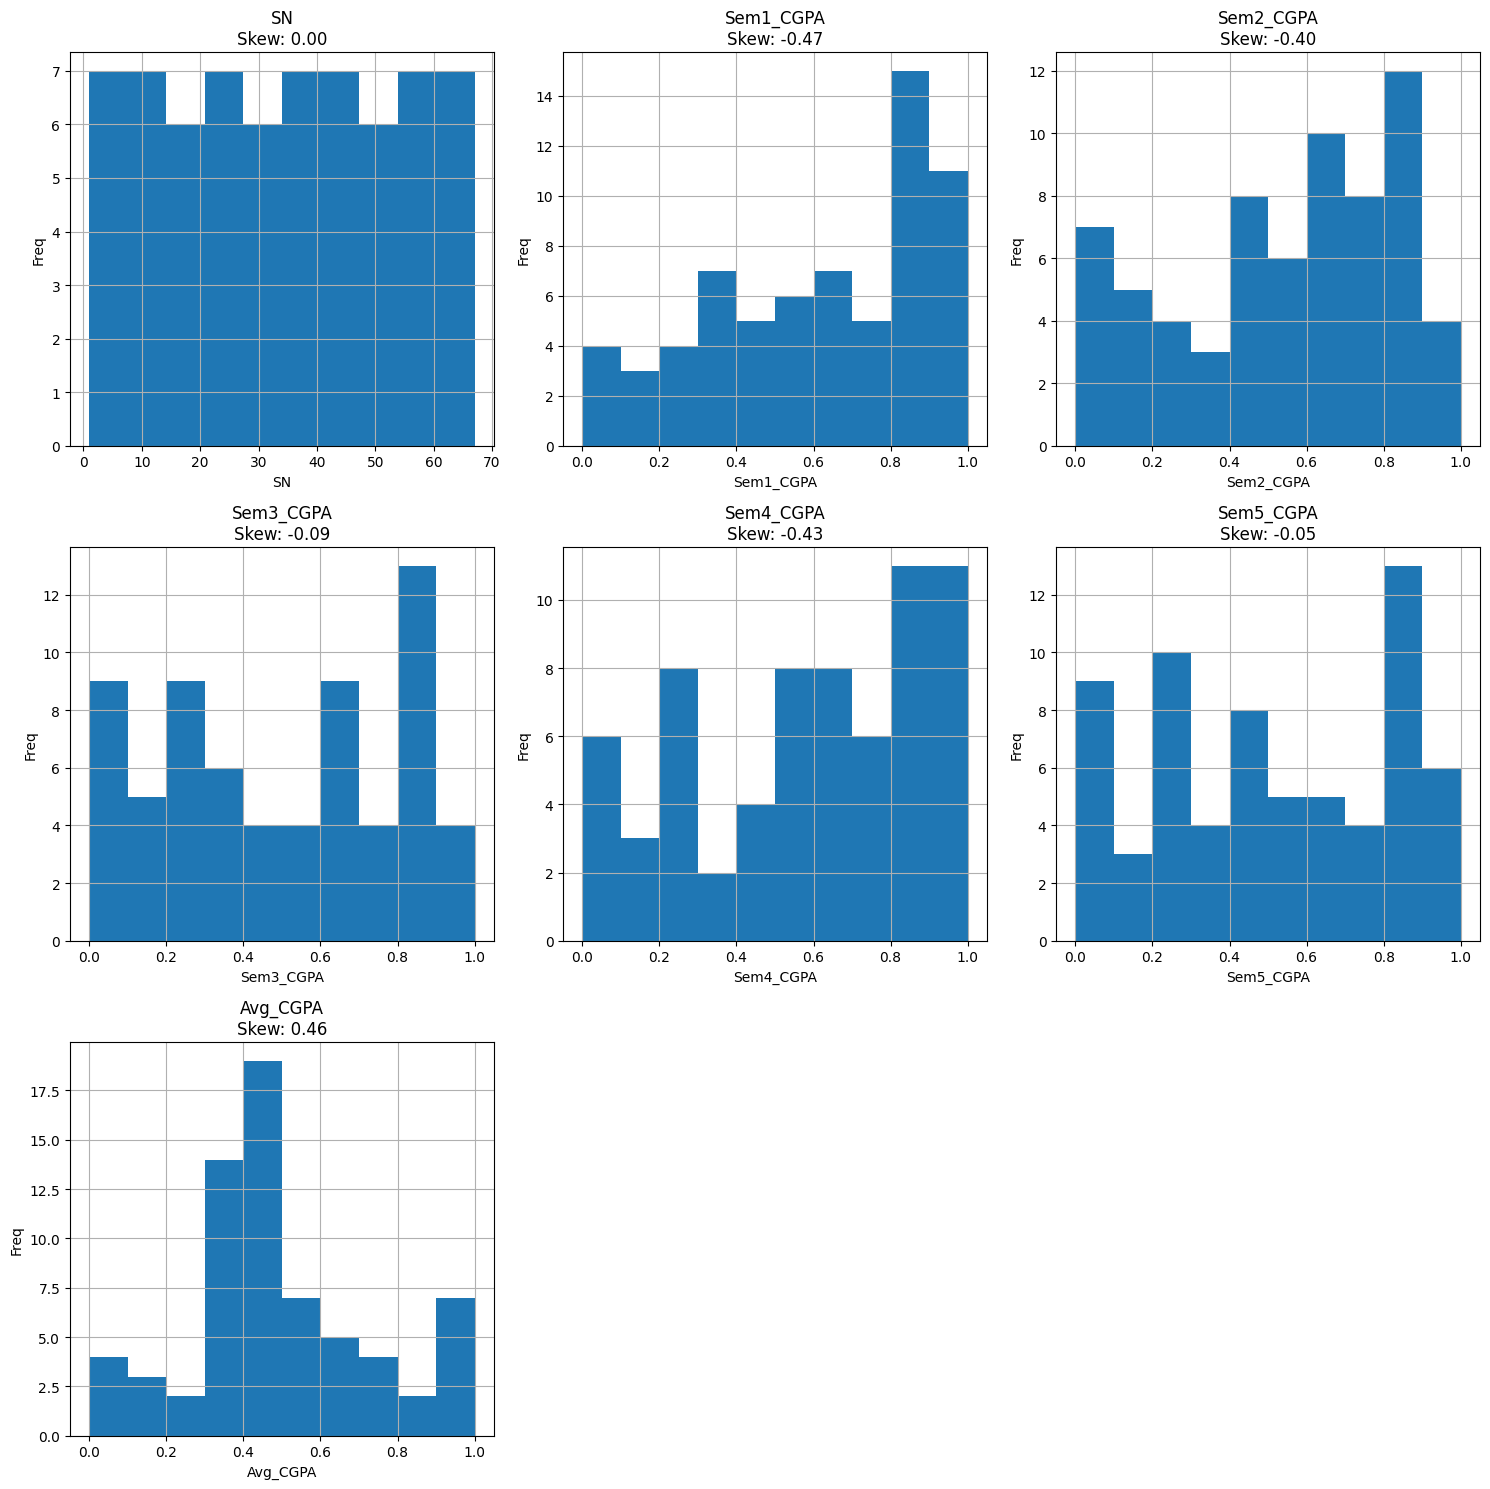

In [16]:
import math

cols = numeric_cols.columns
n = len(cols)
n_cols = 3
n_rows = math.ceil(n / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    numeric_cols[col].hist()
    plt.title(f"{col}\nSkew: {skewness[col]:.2f}")
    plt.xlabel(col)
    plt.ylabel("Freq")

plt.tight_layout()
plt.show()